In [2]:
import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
data = pd.read_csv('AirPassengers_scaled.csv')
data['x'] = range(1, len(data) + 1)

In [4]:
x_train = np.array(data['x'].values)
y_train = np.array(data['Passengers_scaled'].values)

In [5]:
# Parametry systemu
n_qubits = 3
n_ansatz_layers = 1
m_ansatz_layers = 2

def S(x):
    # RX(x) na wszystkich qubitach
    for i in range(n_qubits):
        qml.RX(x, wires=i)

def U_ent(weights):
    qml.StronglyEntanglingLayers(weights, wires=range(n_qubits))

def U_q(weights):
    for idx, w in enumerate(weights):
        qml.Rot(w[0], w[1], w[2], wires=idx)

dev = qml.device("default.qubit", wires=n_qubits)
@qml.qnode(device=dev)
def parralel_quantum_model(weights, x):
    
    U_ent(weights[:n_ansatz_layers])

    qml.Barrier()
    
    U_q(weights[n_ansatz_layers+1])
    
    qml.Barrier()
    
    S(x)
    
    qml.Barrier()

    U_ent(weights[n_ansatz_layers+1:-1])

    qml.Barrier()
    
    U_q(weights[-1])

    obs = qml.prod(*[qml.PauliZ(i) for i in range(n_qubits)])
    #obs = reduce(operator.matmul, [qml.PauliZ(i) for i in range(n_qubits)])
    #print(obs)
    return qml.expval(obs)
    #return qml.expval( [qml.PauliZ(i) for i in range(n_qubits)] )
    #return qml.math.stack([qml.expval(qml.PauliZ(i)) for i in range(n_qubits)])

In [6]:
weights = (np.random.random(size=(n_ansatz_layers+1+m_ansatz_layers+1, n_qubits, 3), requires_grad=True))

(<Figure size 1800x400 with 1 Axes>, <Axes: >)


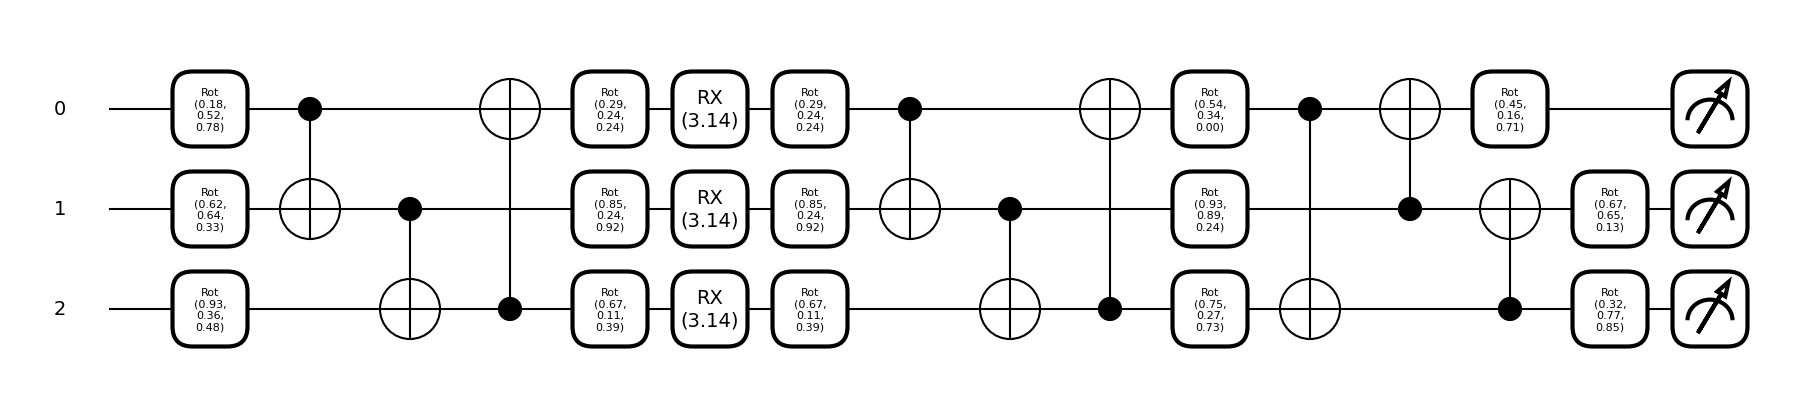

In [7]:
print(qml.draw_mpl(parralel_quantum_model, level="device", decimals=2)(weights, np.pi))

In [8]:
# Koszt: MSE
def cost(weights, x_data, y_data):
    preds = np.array([parralel_quantum_model(weights, x) for x in x_data])
    return np.mean((preds - y_data) ** 2)


# Optymalizacja
opt = qml.AdamOptimizer(stepsize=0.1)
epochs = 100

for epoch in range(epochs):
    weights = opt.step(lambda w: cost(w, x_train, y_train), weights)
    if epoch % 10 == 0:
        loss = cost(weights, x_train, y_train)
        print(f"Epoch {epoch}: loss = {loss:.6f}")


/Users/seba/Desktop/MZBO2025/venv/lib/python3.13/site-packages/pennylane/ops/op_math/composite.py:211: FutureWarning: functools.partial will be a method descriptor in future Python versions; wrap it in staticmethod() if you want to preserve the old behavior
  return self._math_op(math.vstack(eigvals), axis=0)


Epoch 0: loss = 0.249349
Epoch 10: loss = 0.221254
Epoch 20: loss = 0.216517
Epoch 30: loss = 0.214194
Epoch 40: loss = 0.213420
Epoch 50: loss = 0.212989
Epoch 60: loss = 0.212984
Epoch 70: loss = 0.212919
Epoch 80: loss = 0.212915
Epoch 90: loss = 0.212913


In [9]:
preds = np.array([parralel_quantum_model(weights, x ) for x in x_train])

In [13]:
def r2_score_np(y_true, y_pred):
    """Oblicza współczynnik determinacji R² dla numpy arrays"""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - ss_res / ss_tot
    return r2

def mae_np(y_true, y_pred):
    """Mean Absolute Error dla numpy arrays"""
    return np.mean(np.abs(y_true - y_pred))

def rmse_np(y_true, y_pred):
    """Root Mean Squared Error dla numpy arrays"""
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def smape_np(y_true, y_pred, eps=1e-8):
    """Symmetric Mean Absolute Percentage Error dla numpy arrays"""
    return np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred) + eps)) * 100


In [10]:
y_true = y_train
y_pred = preds

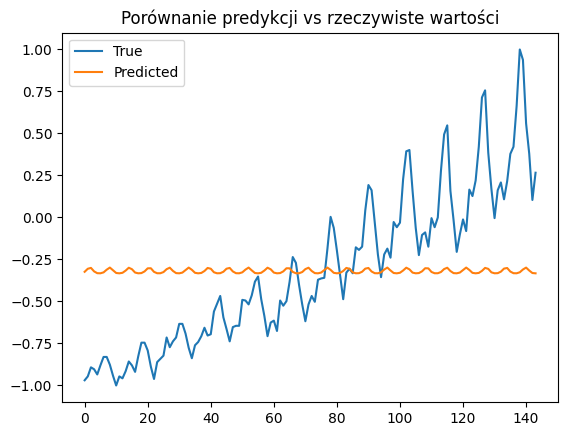

In [11]:
import matplotlib.pyplot as plt

plt.plot(y_true.numpy(), label='True')
plt.plot(y_pred.numpy(), label='Predicted')
plt.legend()
plt.title('Porównanie predykcji vs rzeczywiste wartości')
plt.show()

In [14]:
print(f"R²  ={r2_score_np(y_true, y_pred)}\nMSE  ={cost(weights,x_train, y_train)}" )
print(f"mae  ={mae_np(y_true, y_pred)}\nRMSE ={rmse_np(y_true, y_pred)}" )
print(f"smape ={smape_np(y_true, y_pred)}")

R²  =0.0006745536905168326
MSE  =0.21291174293837087
mae  =0.3879677157094091
RMSE =0.4614236046610217
smape =103.38607894797138
